In [160]:
import numpy as np
import matplotlib.pyplot as plt
import Parameters as Pars
from Two_Par_Variation import TwoDimParVar
from Nanograv_15_year_constraints import interpolate_h_ss_max_Nano_15, get_UL_vs_freq
import h5py
import emcee

In [161]:
par1 = Pars.psi0
par2 = Pars.m0
ranges = dict([par1, par2])

In [162]:
t1 = TwoDimParVar(ranges,bound_type='hc',shape=30,full_analysis=False)

In [152]:
pdf = t1.get_Strain_pdf()

In [153]:
logpdf = np.log10(pdf)

In [154]:
logpdfFreq = logpdf[:,:,0,:,:] #Single frequency

In [155]:
logpdfFreqLoudest = logpdfFreq[:,:,:,0] #Loudest SMBHB

In [156]:
logpdfFreqLoudestSingleReal = logpdfFreqLoudest[:,:,0]

In [157]:
logpdfFreqLoudestSingleReal = np.where(logpdfFreqLoudestSingleReal > 0, logpdfFreqLoudestSingleReal,0)

In [158]:
pranges = t1.par_ranges.values()

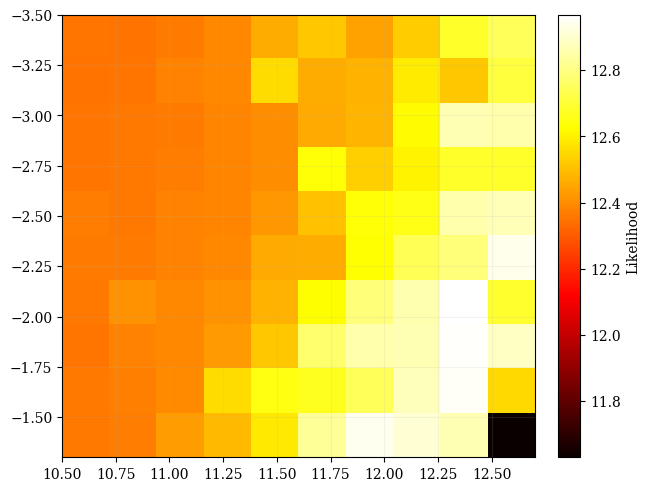

In [159]:
figs, ax = plt.subplots(layout='constrained')
figsize=(16,4)
im = ax.imshow(logpdfFreqLoudestSingleReal, cmap='hot', interpolation='nearest',extent = (list(pranges)[1][0],list(pranges)[1][-1],list(pranges)[0][-1],list(pranges)[0][0]), aspect = 'auto')
#ax.set_xlabel(DistObj.par_names[1],fontsize=16)
#ax.set_ylabel(DistObj.par_names[0],fontsize=16)
figs.colorbar(im,label='Likelihood')